# Hierarchical clustering of top-5 overall force-constant solutions

This notebook loads `dataframe000013.pkl` and `dataframe000014.pkl`, selects the **top 5 overall** solutions for each independent dataset and each `(mass, lattice parameter)` pair, and performs hierarchical clustering in standardized BvK force-constant space,

\[
(\alpha_0,\alpha_1,\beta_1,\alpha_2,\beta_2).
\]

It produces publication-quality dendrograms, cluster-colored PCA projections, \((\alpha_2,\beta_2)\) scatter plots, and a dendrogram-ordered pairwise-distance heat map.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from scipy.spatial.distance import pdist, squareform

%config InlineBackend.figure_format = "retina"

DATA_DIR = Path("./dataframes/")  # Update if needed.

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
}

OUTPUT_DIR = Path("hierarchical_clustering_force_constant_space_top5_overall")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANK_BY = "fitness_norm"

LINKAGE_METHOD = "ward"
N_CLUSTERS = 2

SAVE_FORMATS = ("pdf", "png")
DPI = 300

FIGSIZE = (6.4, 5.2)
MARKER_SIZE = 58
MARKER_ALPHA = 0.86
EDGE_WIDTH = 0.3
ZERO_TOL = 0.08


In [2]:
def find_first_existing(candidates, columns):
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}. Update DATA_DIR or DATAFRAME_FILES.")
    df = pd.read_pickle(path).copy()
    df["dataset"] = dataset_label
    return df


def display_label(col):
    label_map = {
        "mass": r"$m$ (amu)", "m": r"$m$ (amu)",
        "a_val": r"$a$ ($\AA$)", "alat": r"$a$ ($\AA$)",
        "a_latt": r"$a$ ($\AA$)", "lattice_parameter": r"$a$ ($\AA$)",
        "alpha0": r"$\alpha_0$ (N/m)", "alpha_0": r"$\alpha_0$ (N/m)",
        "alpha1": r"$\alpha_1$ (N/m)", "alpha_1": r"$\alpha_1$ (N/m)",
        "beta1": r"$\beta_1$ (N/m)", "beta_1": r"$\beta_1$ (N/m)",
        "alpha2": r"$\alpha_2$ (N/m)", "alpha_2": r"$\alpha_2$ (N/m)",
        "beta2": r"$\beta_2$ (N/m)", "beta_2": r"$\beta_2$ (N/m)",
        "fitness_norm": r"$f_{\mathrm{norm}}$", "fnorm": r"$f_{\mathrm{norm}}$",
        "r_alpha2": r"$r_{\alpha_2}$",
        "delta_alpha2_beta2": r"$|\alpha_2|-|\beta_2|$",
        "cluster": "Cluster",
    }
    return label_map.get(col, col)


def apply_publication_axes(ax):
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True,
                   labelsize=12, length=5, width=1.1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)


def save_figure(fig, stem, output_dir=OUTPUT_DIR, formats=SAVE_FORMATS):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    print("Saved:")
    for path in saved:
        print(f"  {path}")
    return saved


def classify_family(row, alpha2_col, beta2_col, zero_tol=ZERO_TOL):
    a2 = row[alpha2_col]
    b2 = row[beta2_col]
    if abs(b2) <= zero_tol and abs(a2) > zero_tol:
        return r"$\alpha_2$-dominated"
    if abs(a2) <= zero_tol and abs(b2) > zero_tol:
        return r"$\beta_2$-dominated"
    if abs(a2) > abs(b2):
        return r"$\alpha_2$ larger"
    if abs(b2) > abs(a2):
        return r"$\beta_2$ larger"
    return "balanced"


In [3]:
frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe before filtering: {df_all.shape[0]:,} rows")
df_all.head()


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe before filtering: 420,000 rows


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path,dataset
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013


In [4]:
mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

alpha0_col = find_first_existing(["alpha0", "alpha_0"], df_all.columns)
alpha1_col = find_first_existing(["alpha1", "alpha_1"], df_all.columns)
beta1_col  = find_first_existing(["beta1", "beta_1"], df_all.columns)
alpha2_col = find_first_existing(["alpha2", "alpha_2"], df_all.columns)
beta2_col  = find_first_existing(["beta2", "beta_2"], df_all.columns)

force_constant_cols = [alpha0_col, alpha1_col, beta1_col, alpha2_col, beta2_col]

required = {
    "mass": mass_col,
    "lattice parameter": alat_col,
    "ranking": rank_col,
    "alpha0": alpha0_col,
    "alpha1": alpha1_col,
    "beta1": beta1_col,
    "alpha2": alpha2_col,
    "beta2": beta2_col,
}

for name, col in required.items():
    if col is None:
        raise ValueError(f"Could not find required column for {name}.")

print("Detected columns:")
for name, col in required.items():
    print(f"{name:20s}: {col}")


Detected columns:
mass                : mass
lattice parameter   : a_val
ranking             : fitness_norm
alpha0              : alpha0
alpha1              : alpha1
beta1               : beta1
alpha2              : alpha2
beta2               : beta2


In [5]:
df_top = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

for col in [mass_col, alat_col, rank_col] + force_constant_cols:
    df_top[col] = pd.to_numeric(df_top[col], errors="coerce")

df_top = df_top.dropna(subset=[mass_col, alat_col, rank_col] + force_constant_cols).copy()

df_top["abs_alpha2"] = df_top[alpha2_col].abs()
df_top["abs_beta2"] = df_top[beta2_col].abs()
df_top["r_alpha2"] = df_top["abs_alpha2"] / (df_top["abs_alpha2"] + df_top["abs_beta2"] + 1e-12)
df_top["delta_alpha2_beta2"] = df_top["abs_alpha2"] - df_top["abs_beta2"]
df_top["family"] = df_top.apply(lambda row: classify_family(row, alpha2_col, beta2_col), axis=1)

print(f"Rows after top-{TOP_K}-overall selection: {df_top.shape[0]:,}")
print(df_top["family"].value_counts())
df_top[["dataset", mass_col, alat_col, rank_col] + force_constant_cols + ["r_alpha2", "family"]].head()


Rows after top-5-overall selection: 840
family
$\beta_2$-dominated     600
$\alpha_2$-dominated    205
$\beta_2$ larger         20
$\alpha_2$ larger        15
Name: count, dtype: int64


,dataset,mass,a_val,fitness_norm,alpha0,alpha1,beta1,alpha2,beta2,r_alpha2,family
214621,dataframe000015,50.0,2.2,1.731862,5.173158,-0.321338,-0.017194,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214938,dataframe000015,50.0,2.2,1.731862,5.173158,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214926,dataframe000015,50.0,2.2,1.731862,5.173158,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214927,dataframe000015,50.0,2.2,1.731862,5.173158,-0.321338,0.631618,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214928,dataframe000015,50.0,2.2,1.731862,5.173158,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated


In [6]:
X = df_top[force_constant_cols].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dist_vec = pdist(X_scaled, metric="euclidean")
dist_mat = squareform(dist_vec)

Z = linkage(X_scaled, method=LINKAGE_METHOD, metric="euclidean")

df_top["cluster"] = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

print(f"Linkage method: {LINKAGE_METHOD}")
print(f"Number of clusters: {N_CLUSTERS}")

print("\nCluster counts:")
print(df_top["cluster"].value_counts().sort_index())

print("\nCluster vs. alpha2/beta2 family:")
cluster_family_table = pd.crosstab(df_top["cluster"], df_top["family"])
cluster_family_table


Linkage method: ward
Number of clusters: 2

Cluster counts:
cluster
1    172
2    668
Name: count, dtype: int64

Cluster vs. alpha2/beta2 family:


family,$\alpha_2$ larger,$\alpha_2$-dominated,$\beta_2$ larger,$\beta_2$-dominated
cluster,,,,
1,0,166,6,0
2,15,39,14,600


Saved:
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_full_dendrogram.pdf
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_full_dendrogram.png


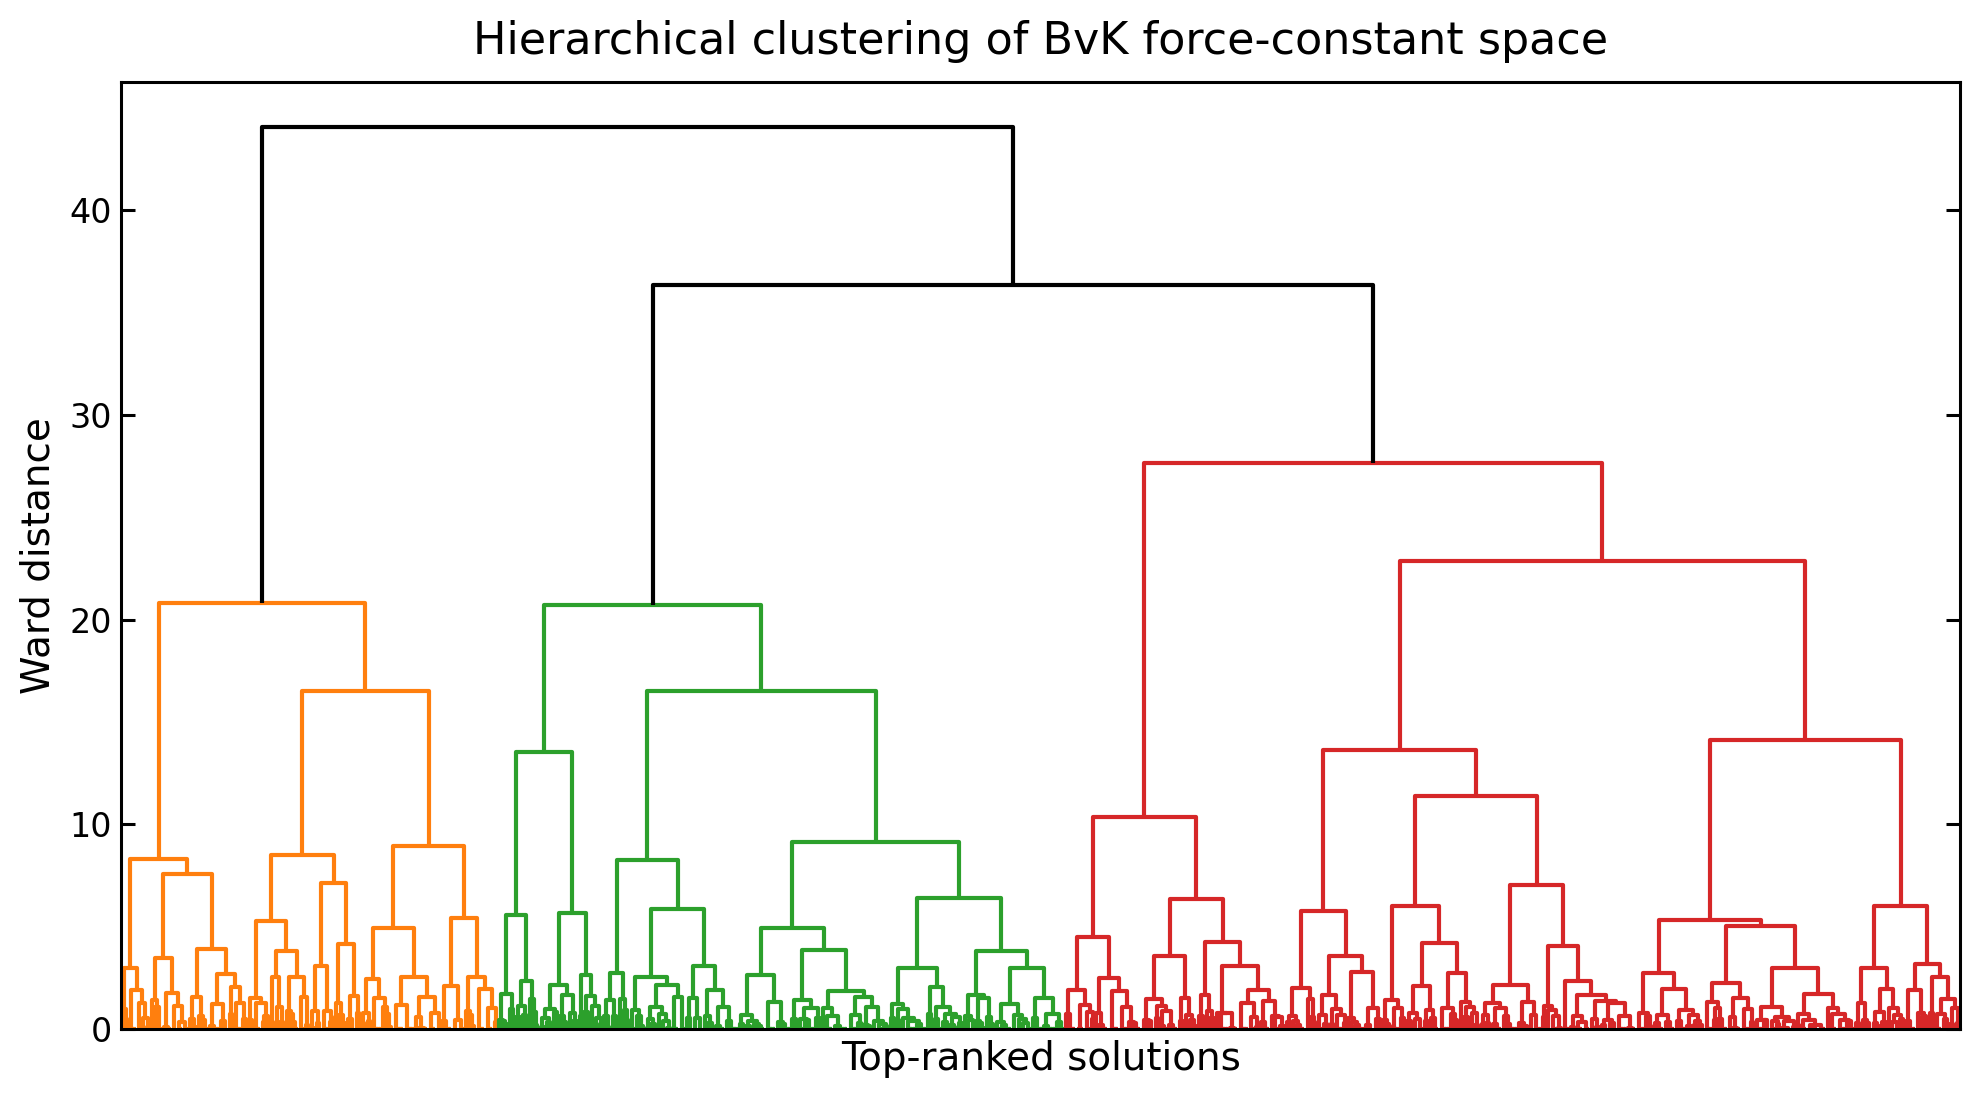

In [7]:
fig, ax = plt.subplots(figsize=(10.0, 5.6))

dendrogram(
    Z,
    ax=ax,
    no_labels=True,
    color_threshold=None,
    above_threshold_color="black",
)

ax.set_title("Hierarchical clustering of BvK force-constant space", fontsize=16, pad=10)
ax.set_xlabel("Top-ranked solutions", fontsize=14)
ax.set_ylabel("Ward distance", fontsize=14)

apply_publication_axes(ax)

fig.tight_layout()
save_figure(fig, "hierarchical_clustering_full_dendrogram")
plt.show()


Saved:
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_truncated_dendrogram.pdf
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_truncated_dendrogram.png


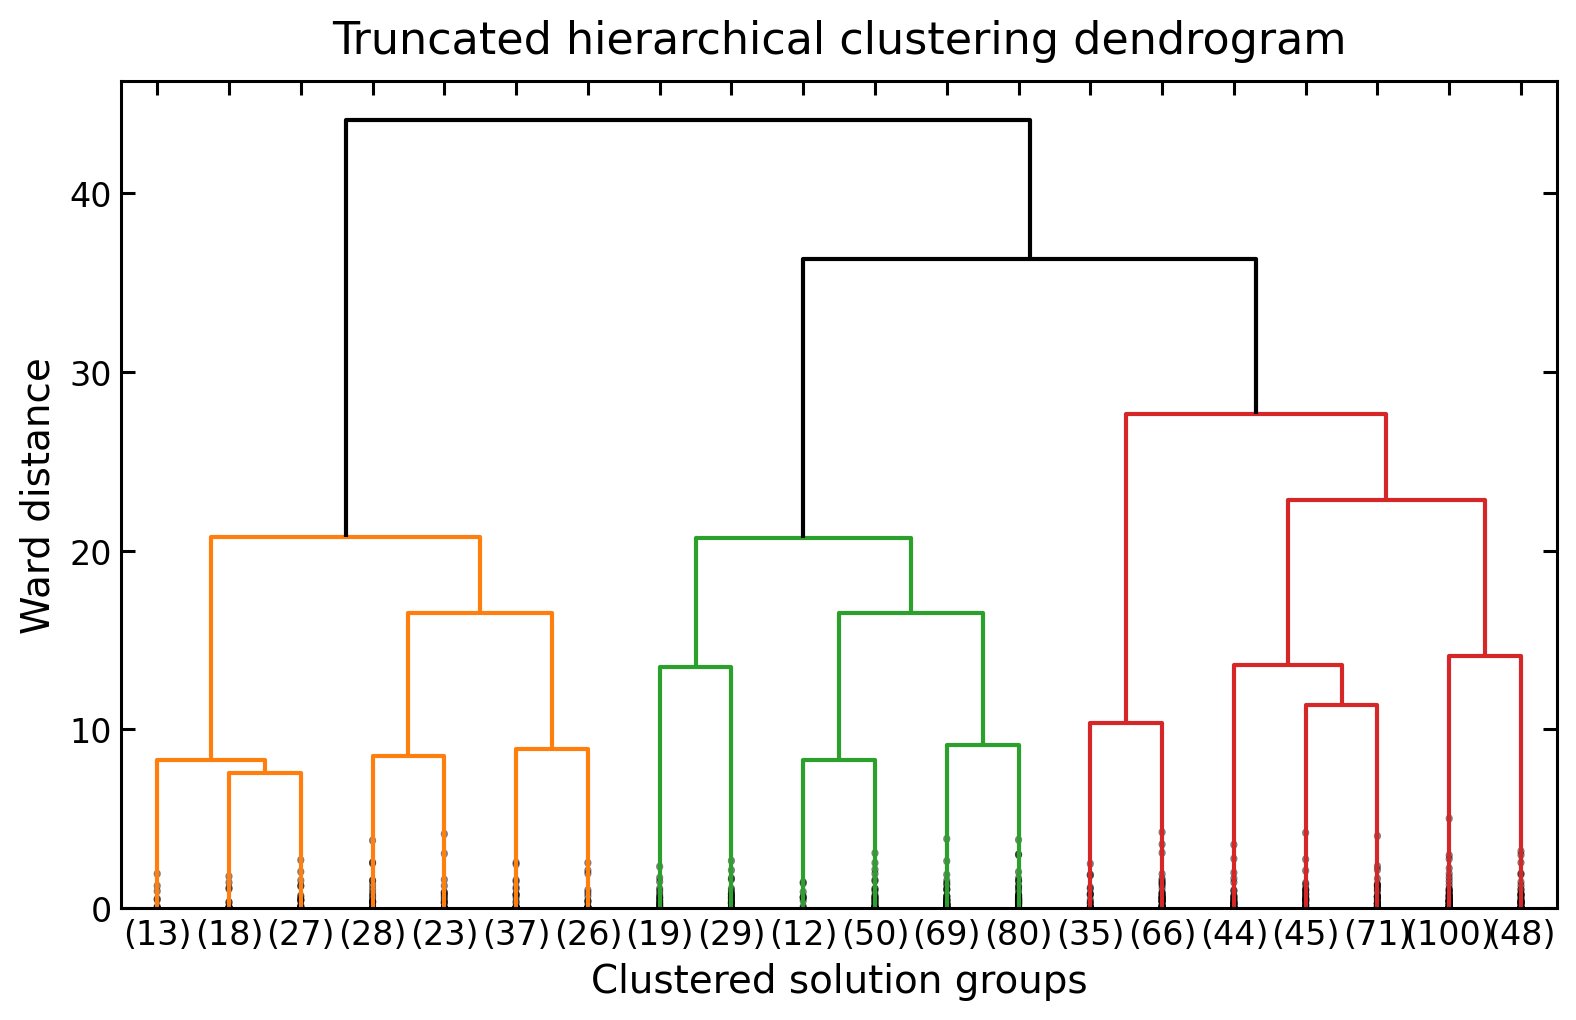

In [8]:
fig, ax = plt.subplots(figsize=(8.0, 5.2))

dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=20,
    show_contracted=True,
    color_threshold=None,
    above_threshold_color="black",
)

ax.set_title("Truncated hierarchical clustering dendrogram", fontsize=16, pad=10)
ax.set_xlabel("Clustered solution groups", fontsize=14)
ax.set_ylabel("Ward distance", fontsize=14)

apply_publication_axes(ax)

fig.tight_layout()
save_figure(fig, "hierarchical_clustering_truncated_dendrogram")
plt.show()


Explained variance ratio:
PC1: 0.3821
PC2: 0.2978
PC3: 0.1986
PC4: 0.1215
PC5: 0.0000
Saved:
  hierarchical_clustering_force_constant_space_top5_overall/pca_projection_colored_by_hierarchical_cluster.pdf
  hierarchical_clustering_force_constant_space_top5_overall/pca_projection_colored_by_hierarchical_cluster.png


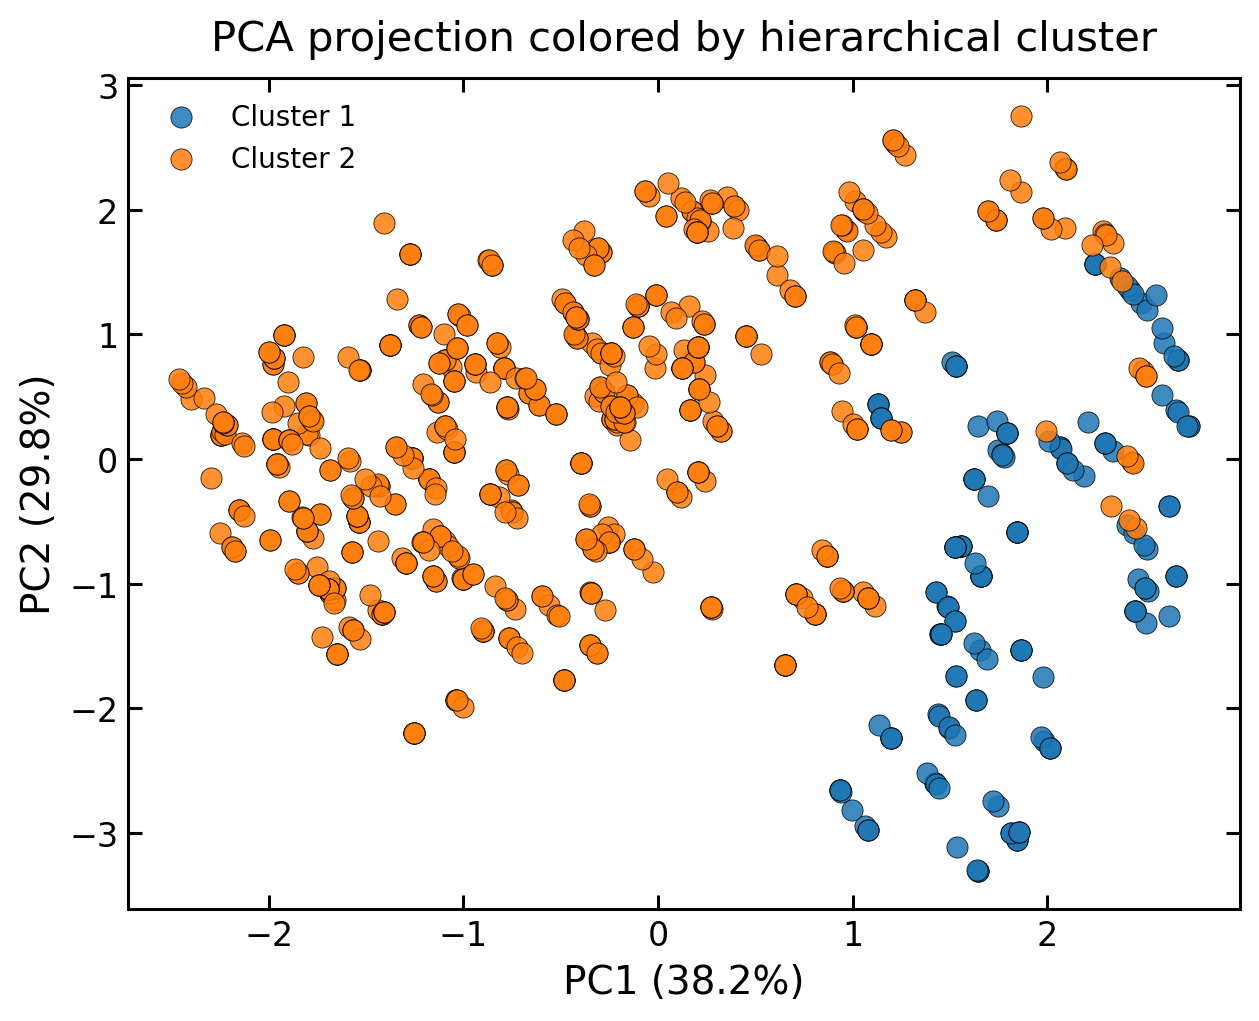

In [9]:
pca = PCA(n_components=5)
scores = pca.fit_transform(X_scaled)

df_top["PC1"] = scores[:, 0]
df_top["PC2"] = scores[:, 1]

explained = pca.explained_variance_ratio_

print("Explained variance ratio:")
for i, val in enumerate(explained, start=1):
    print(f"PC{i}: {val:.4f}")

fig, ax = plt.subplots(figsize=FIGSIZE)

for cluster_id, sub in df_top.groupby("cluster"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=MARKER_SIZE,
        alpha=MARKER_ALPHA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
        label=f"Cluster {cluster_id}",
    )

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=14)
ax.set_title("PCA projection colored by hierarchical cluster", fontsize=15, pad=10)

apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=10, loc="best")

fig.tight_layout()
save_figure(fig, "pca_projection_colored_by_hierarchical_cluster")
plt.show()


Saved:
  hierarchical_clustering_force_constant_space_top5_overall/beta2_vs_alpha2_colored_by_hierarchical_cluster.pdf
  hierarchical_clustering_force_constant_space_top5_overall/beta2_vs_alpha2_colored_by_hierarchical_cluster.png


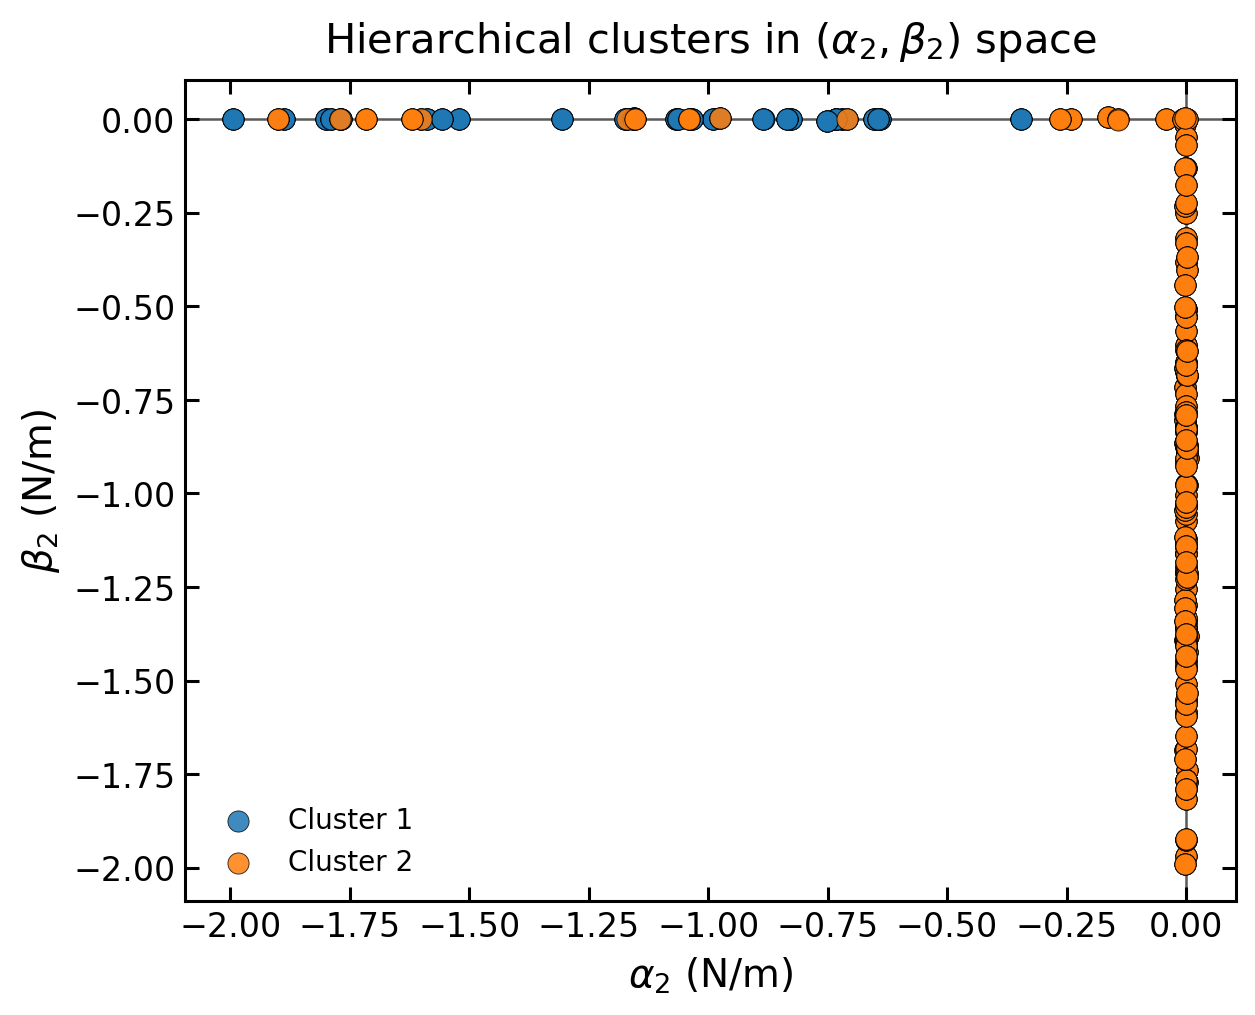

In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for cluster_id, sub in df_top.groupby("cluster"):
    ax.scatter(
        sub[alpha2_col],
        sub[beta2_col],
        s=MARKER_SIZE,
        alpha=MARKER_ALPHA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
        label=f"Cluster {cluster_id}",
    )

ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

ax.set_xlabel(display_label(alpha2_col), fontsize=14)
ax.set_ylabel(display_label(beta2_col), fontsize=14)
ax.set_title(r"Hierarchical clusters in $(\alpha_2,\beta_2)$ space", fontsize=15, pad=10)

apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=10, loc="best")

fig.tight_layout()
save_figure(fig, "beta2_vs_alpha2_colored_by_hierarchical_cluster")
plt.show()


Saved:
  hierarchical_clustering_force_constant_space_top5_overall/pairwise_distance_heatmap_ordered_by_dendrogram.pdf
  hierarchical_clustering_force_constant_space_top5_overall/pairwise_distance_heatmap_ordered_by_dendrogram.png


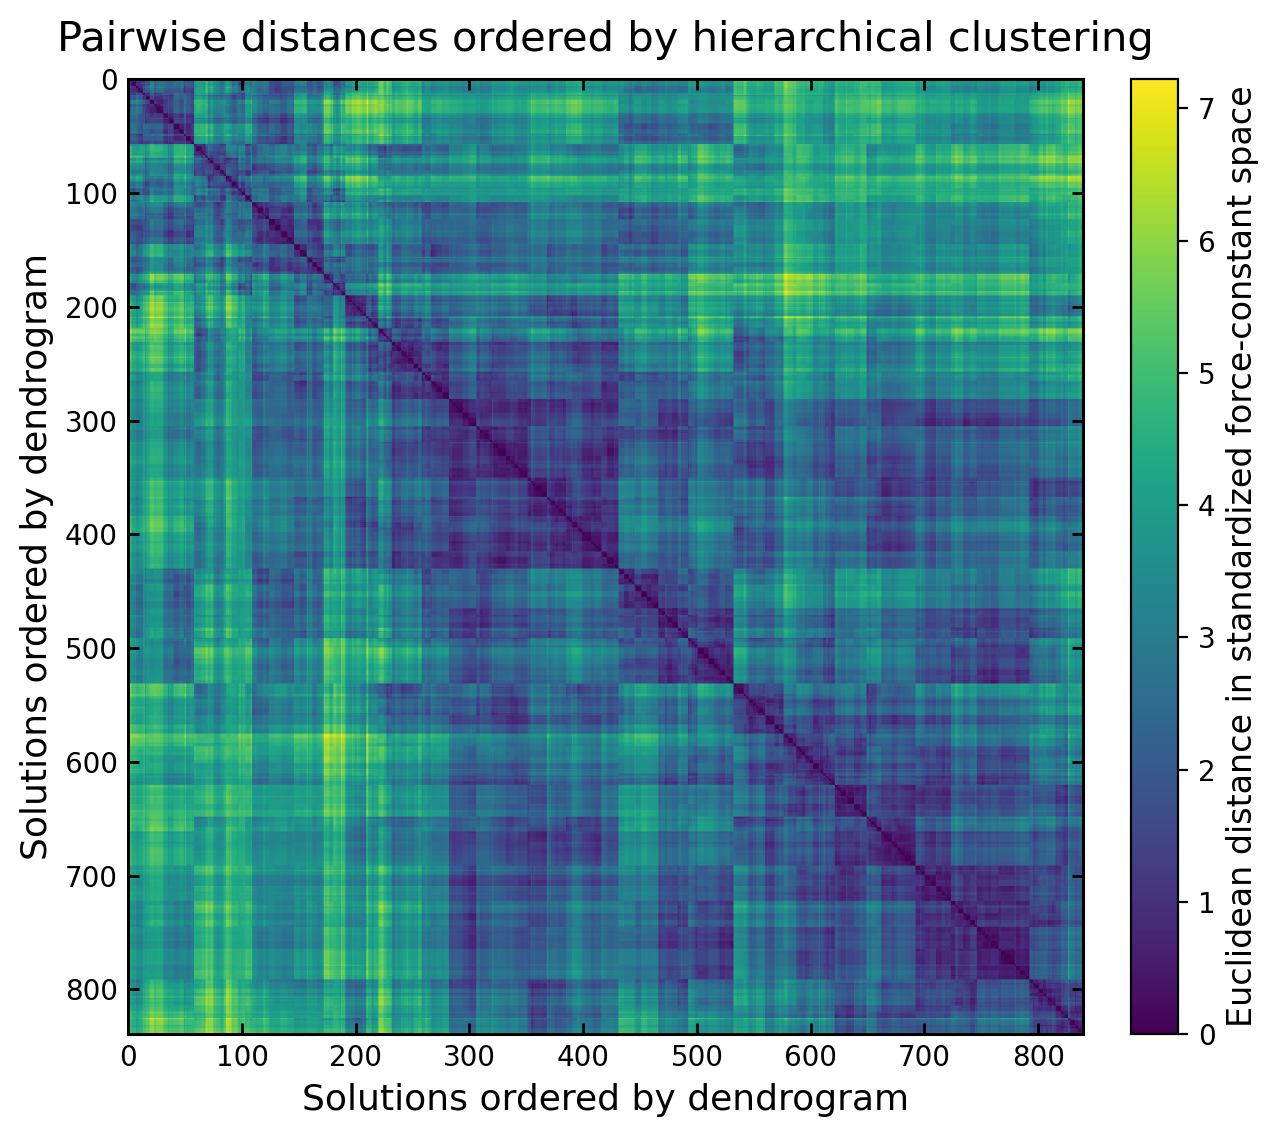

In [11]:
leaf_order = leaves_list(Z)
ordered_dist = dist_mat[np.ix_(leaf_order, leaf_order)]

fig, ax = plt.subplots(figsize=(6.8, 5.8))

im = ax.imshow(ordered_dist, origin="upper", cmap="viridis")

ax.set_title("Pairwise distances ordered by hierarchical clustering", fontsize=15, pad=10)
ax.set_xlabel("Solutions ordered by dendrogram", fontsize=13)
ax.set_ylabel("Solutions ordered by dendrogram", fontsize=13)

ax.tick_params(axis="both", which="both", direction="in", top=True, right=True,
               labelsize=10, length=4, width=1.0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Euclidean distance in standardized force-constant space", fontsize=12)
cbar.ax.tick_params(labelsize=10)

fig.tight_layout()
save_figure(fig, "pairwise_distance_heatmap_ordered_by_dendrogram")
plt.show()


In [12]:
summary_cols = [
    mass_col,
    alat_col,
    rank_col,
    alpha0_col,
    alpha1_col,
    beta1_col,
    alpha2_col,
    beta2_col,
    "r_alpha2",
    "delta_alpha2_beta2",
]

cluster_summary = (
    df_top.groupby("cluster")[summary_cols]
    .agg(["count", "mean", "std", "min", "max"])
)

cluster_summary


mass                                    a_val                      \
        count       mean        std   min    max count      mean       std   
cluster                                                                      
1         172  75.058136  17.786818  50.0  100.0   172  2.661628  0.393119   
2         668  74.985031  16.917645  50.0  100.0   668  2.584132  0.400808   

                   ... r_alpha2                                          \
         min  max  ...    count      mean       std       min       max   
cluster            ...                                                    
1        2.0  3.2  ...      172  0.975719  0.127429  0.173518  0.999995   
2        2.0  3.2  ...      668  0.081757  0.266051  0.000004  0.999900   

        delta_alpha2_beta2                                          
                     count      mean       std       min       max  
cluster                                                             
1                      172  1.132117  0.490234 -0.010551  1.993884  
2                      668 -0.898131  0.652446 -1.987556  1.900388  

[2 rows x 50 columns]

In [13]:
df_out = OUTPUT_DIR / "hierarchical_clustering_top5_overall_dataset.csv"
summary_out = OUTPUT_DIR / "hierarchical_clustering_cluster_summary.csv"
crosstab_out = OUTPUT_DIR / "hierarchical_clustering_cluster_vs_family.csv"

df_top.to_csv(df_out, index=False)
cluster_summary.to_csv(summary_out)
cluster_family_table.to_csv(crosstab_out)

print("Saved:")
print(f"  {df_out}")
print(f"  {summary_out}")
print(f"  {crosstab_out}")


Saved:
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_top5_overall_dataset.csv
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_cluster_summary.csv
  hierarchical_clustering_force_constant_space_top5_overall/hierarchical_clustering_cluster_vs_family.csv


## Interpretation guide

If the dendrogram separates into two dominant branches and the flat clusters correspond closely to the \(\alpha_2\)- and \(\beta_2\)-dominated families, then the two-family structure is supported by an independent distance-based method.

PCA and t-SNE visualize the structure after dimensionality reduction. Hierarchical clustering instead uses distances in the original standardized five-dimensional force-constant space. Agreement among these methods provides strong evidence that the optimized BvK parameterizations occupy two distinct regions of force-constant space.
